# LDA Baseline Model
**Modeling**

Implements a Latent Dirichlet Allocation (LDA) baseline following the CRISP-DM modeling phase.  
Library: `gensim`.  
Input: page-level token lists produced by `src/utils.py`.  
Granularity: one document = one slide page (≥ 10 tokens after preprocessing).

**Structure:**
1. Setup & Data Loading
2. Corpus Preparation (dictionary + BoW)
3. Model Training
4. Topic Inspection
5. Evaluation (Coherence & Perplexity)

---
## 1. Setup & Data Loading

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# make src/ importable from within notebooks/
_nb_dir = os.path.dirname(os.path.abspath('lda.ipynb'))
_src_dir = os.path.abspath(os.path.join(_nb_dir, '..'))
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

warnings.filterwarnings('ignore')

# plotting style
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'font.family'      : 'serif',
})
PALETTE = ['#2C5F8A', '#4C9BE8', '#A8C8E8', '#D9E8F5']

print('Libraries loaded.')

Libraries loaded.


In [2]:
from utils import load_corpus, tokenize_corpus, build_slide_page_docs

# load and tokenise
corpus = tokenize_corpus(load_corpus())

# aggregate to page level; drop pages with fewer than 10 tokens
MIN_TOKENS = 10
docs = build_slide_page_docs(corpus)
docs = docs[docs['n_tokens'] >= MIN_TOKENS].reset_index(drop=True)

print(f'Documents (pages): {len(docs)}')
print(f'Token count — min: {docs.n_tokens.min()}, median: {docs.n_tokens.median():.0f}, max: {docs.n_tokens.max()}')
docs.head()

Dropping 6 empty pages after tokenisation.


Documents (pages): 121
Token count — min: 10, median: 21, max: 69


,source_file,page,tokens,n_tokens
0,icd_1_v1_cleaned_v7.csv,5,"[logístico, conteúdo, informação, plataforma, ...",24
1,icd_1_v1_cleaned_v7.csv,6,"[unidade, curricular, objetivo, contacto, ciên...",39
2,icd_1_v1_cleaned_v7.csv,7,"[processo, pedagógico, aplicação, prático, est...",26
3,icd_1_v1_cleaned_v7.csv,8,"[sucesso, capaz, necessidade, existência, prát...",27
4,icd_1_v1_cleaned_v7.csv,9,"[avaliação, avaliação, periódico, modalidade, ...",33


---
## 2. Corpus Preparation

In [3]:
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

RANDOM_SEED = 42

texts = docs['tokens'].tolist()

# build dictionary — filter extremes to reduce noise
# no_below: ignore terms appearing in fewer than 2 documents
# no_above: ignore terms appearing in more than 80% of documents
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.8)
dictionary.compactify()

bow_corpus = [dictionary.doc2bow(text) for text in texts]

print(f'Vocabulary size (after filtering): {len(dictionary)}')
print(f'Corpus size: {len(bow_corpus)} documents')

Vocabulary size (after filtering): 419
Corpus size: 121 documents


---
## 3. Model Training

In [4]:
from gensim.models import LdaModel

NUM_TOPICS  = 10   # aligned with lda_tomotopy.ipynb (k=10 validated by tomotopy grid search)
PASSES      = 20
ITERATIONS  = 400
ALPHA       = 0.1   # symmetric Dirichlet prior on document-topic; matches tomotopy default
ETA         = 0.01  # symmetric Dirichlet prior on topic-word; matches tomotopy default

lda = LdaModel(
    corpus           = bow_corpus,
    id2word          = dictionary,
    num_topics       = NUM_TOPICS,
    passes           = PASSES,
    iterations       = ITERATIONS,
    alpha            = ALPHA,
    eta              = ETA,
    random_state     = RANDOM_SEED,
    per_word_topics  = True,
)

print(f'LDA trained: {NUM_TOPICS} topics, {PASSES} passes, seed={RANDOM_SEED}')

LDA trained: 10 topics, 20 passes, seed=42


---
## 4. Topic Inspection

In [5]:
# top terms per topic
TOP_N = 10
for i, topic in lda.print_topics(num_topics=NUM_TOPICS, num_words=TOP_N):
    print(f'Topic {i:02d}: {topic}')

Topic 00: 0.076*"variável" + 0.042*"regressão" + 0.036*"categórico" + 0.028*"features" + 0.027*"target" + 0.024*"numérico" + 0.021*"correlação" + 0.017*"previsão" + 0.014*"logístico" + 0.014*"linear"
Topic 01: 0.058*"modelo" + 0.053*"resultado" + 0.028*"projeto" + 0.021*"modelação" + 0.021*"população" + 0.021*"estudante" + 0.021*"amostra" + 0.021*"intervenção" + 0.021*"solução" + 0.021*"relatório"
Topic 02: 0.050*"outlier" + 0.036*"visualização" + 0.034*"análise" + 0.032*"valores" + 0.027*"cliente" + 0.027*"identificação" + 0.023*"conhecimento" + 0.018*"fonte" + 0.016*"resultado" + 0.014*"contexto"
Topic 03: 0.082*"modelo" + 0.049*"artificial" + 0.049*"padrão" + 0.035*"erro" + 0.035*"inteligência" + 0.035*"generativo" + 0.035*"rede" + 0.028*"real" + 0.021*"conteúdo" + 0.021*"genai"
Topic 04: 0.046*"cluster" + 0.036*"distância" + 0.028*"passo" + 0.027*"árvore" + 0.027*"false" + 0.027*"rate" + 0.027*"variável" + 0.023*"direito" + 0.023*"positive" + 0.022*"atributo"
Topic 05: 0.079*"objet

In [6]:
from utils import generate_topic_labels

TOPIC_LABELS = generate_topic_labels(lda, NUM_TOPICS, topn=3)

for idx, label in TOPIC_LABELS.items():
    print(f'T{idx:02d}: {label}')

T00: Variável · Regressão · Categórico
T01: Modelo · Resultado · Projeto
T02: Outlier · Visualização · Análise
T03: Modelo · Artificial · Padrão
T04: Cluster · Distância · Passo
T05: Objetivo · Modelo · Processo
T06: Informação · Modelo · Conhecimento
T07: Modelo · Treino · Ciência
T08: Processo · Avaliação · Padrão
T09: Valores · Numérico · Omisso


In [12]:

# topic summary table
rows = []
for i in range(NUM_TOPICS):
    terms = lda.show_topic(i, topn=TOP_N)
    top_words   = ', '.join(w for w, _ in terms)
    top_weights = [round(p, 3) for _, p in terms]
    rows.append({
        'Topic': f'T{i:02d}',
        'Label': TOPIC_LABELS[i],
        'Top 10 Terms': top_words,
        'Max weight': max(top_weights),
    })

topic_df = pd.DataFrame(rows).set_index('Topic')

topic_df.style \
    .set_caption('LDA Topics — Top 10 Terms per Topic (gensim)') \
    .set_properties(**{'text-align': 'left'}) \
    .bar(subset=['Max weight'], color="#0156AB", vmin=0, vmax=0.15)


,Label,Top 10 Terms,Max weight
Topic,,,
T00,Variável · Regressão · Categórico,"variável, regressão, categórico, features, target, numérico, correlação, previsão, logístico, linear",0.076000
T01,Modelo · Resultado · Projeto,"modelo, resultado, projeto, modelação, população, estudante, amostra, intervenção, solução, relatório",0.058000
T02,Outlier · Visualização · Análise,"outlier, visualização, análise, valores, cliente, identificação, conhecimento, fonte, resultado, contexto",0.050000
T03,Modelo · Artificial · Padrão,"modelo, artificial, padrão, erro, inteligência, generativo, rede, real, conteúdo, genai",0.082000
T04,Cluster · Distância · Passo,"cluster, distância, passo, árvore, false, rate, variável, direito, positive, atributo",0.046000
T05,Objetivo · Modelo · Processo,"objetivo, modelo, processo, business, extração, resultado, aprendizagem, previsão, negócio, avaliação",0.079000
T06,Informação · Modelo · Conhecimento,"informação, modelo, conhecimento, imagem, visualização, análise, conteúdo, information, contexto, humano",0.064000
T07,Modelo · Treino · Ciência,"modelo, treino, ciência, atributo, model, dataset, training, conjunto, construção, base",0.078000
T08,Processo · Avaliação · Padrão,"processo, avaliação, padrão, informação, conjunto, classificação, aprendizagem, projeto, problema, aluno",0.031000


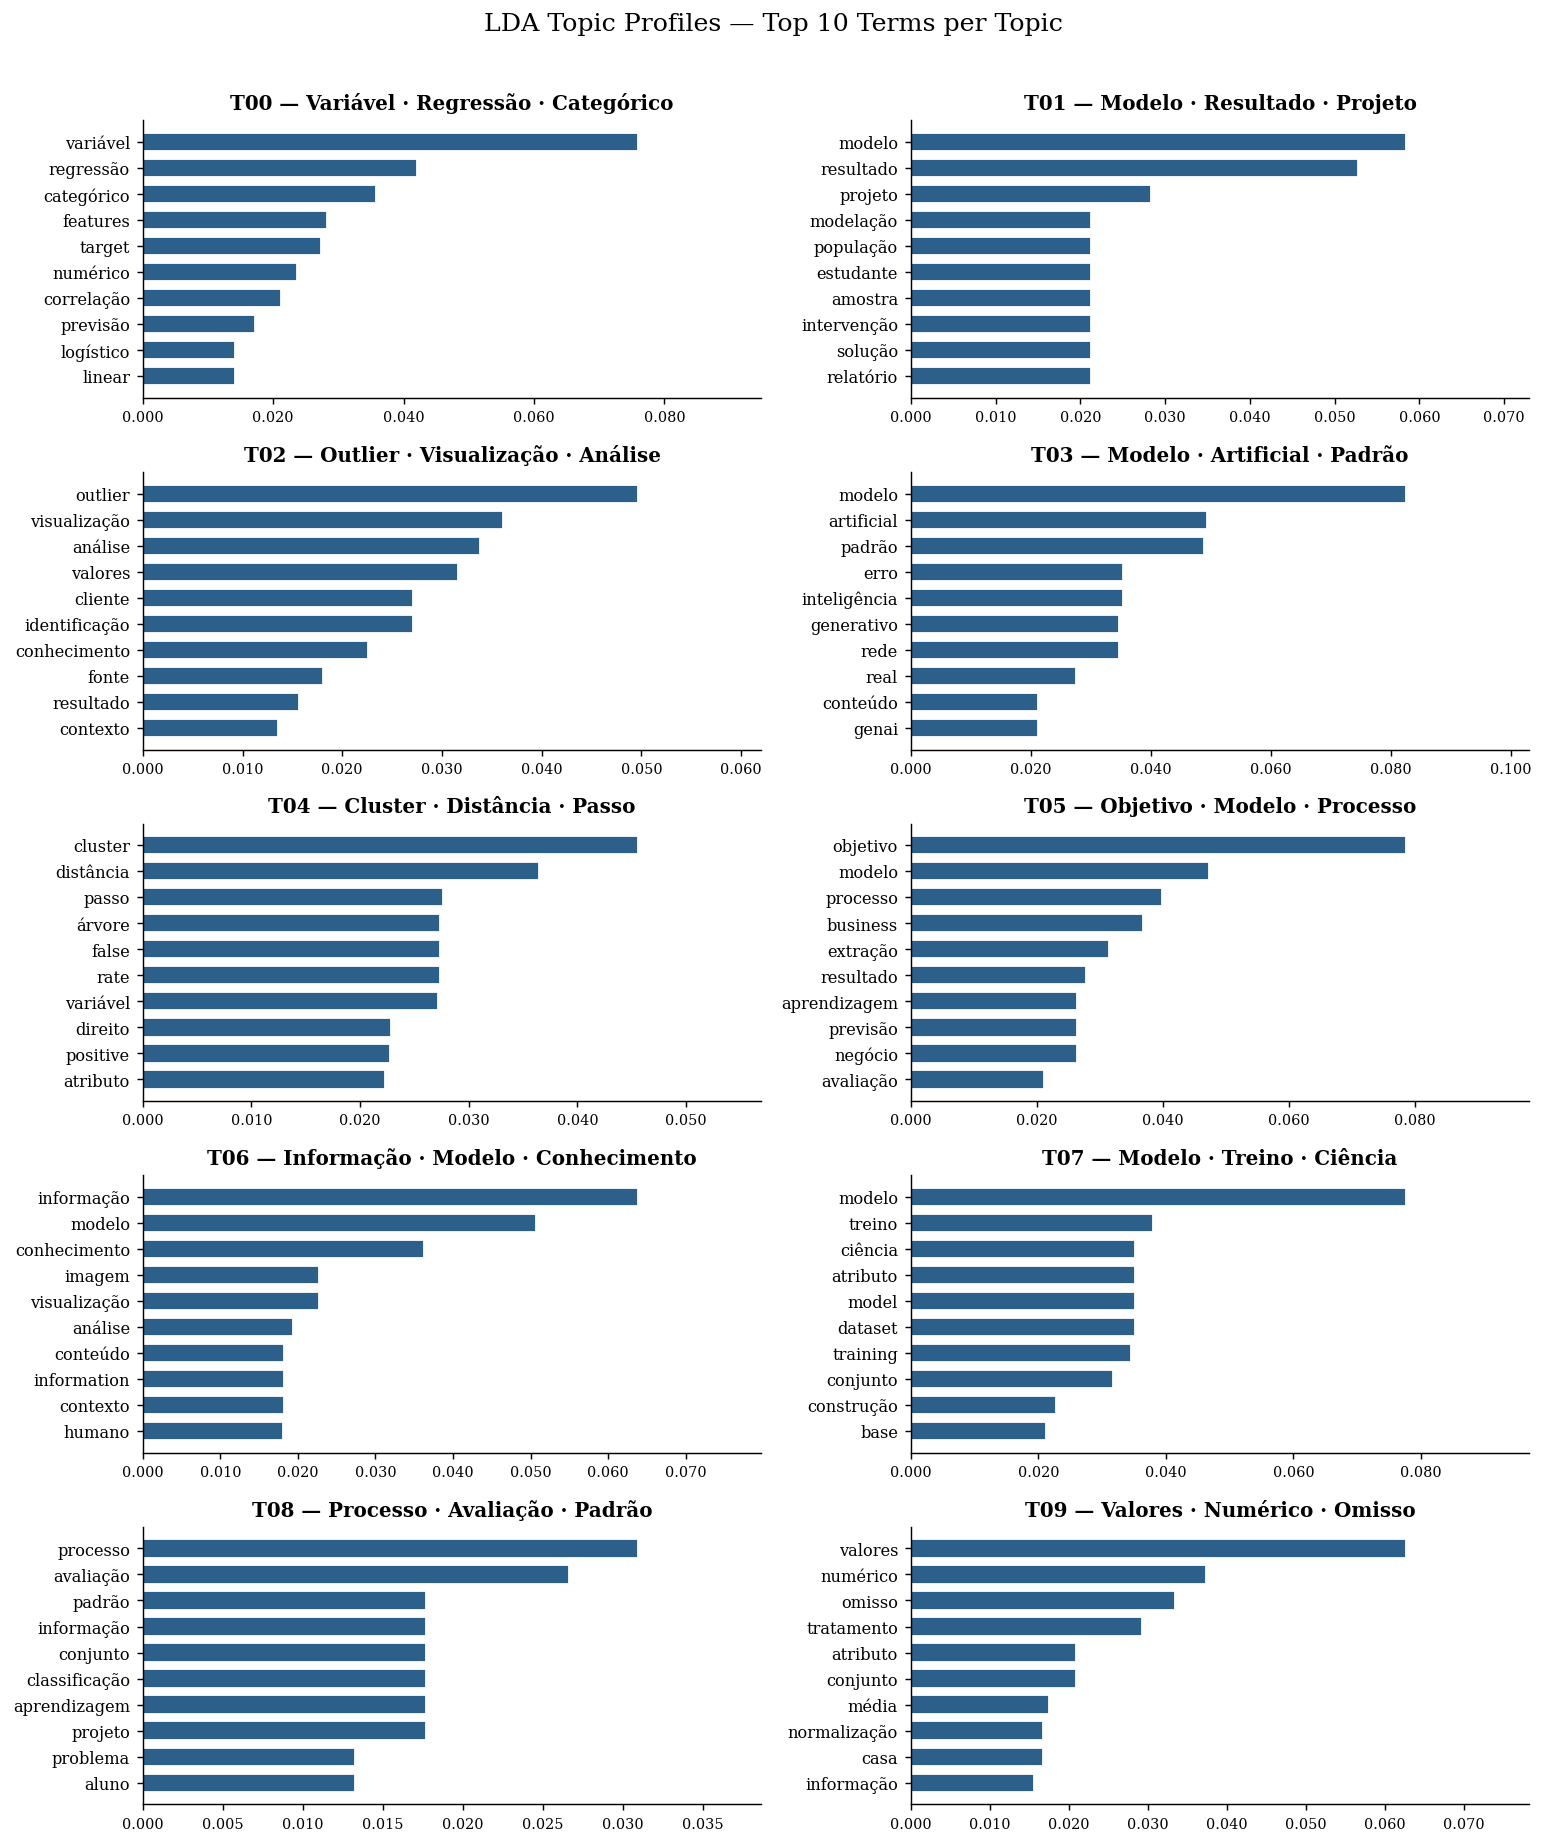

In [8]:
TOP_VIS = 10
n_cols = 2
n_rows = (NUM_TOPICS + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 2.8))
axes = axes.flatten()

for i in range(NUM_TOPICS):
    terms = lda.show_topic(i, topn=TOP_VIS)
    words   = [w for w, _ in terms][::-1]
    weights = [p for _, p in terms][::-1]

    ax = axes[i]
    bars = ax.barh(words, weights, color=PALETTE[0], edgecolor='white', height=0.7)
    ax.set_title(f'T{i:02d} — {TOPIC_LABELS[i]}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, max(weights) * 1.25)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# hide unused subplots
for j in range(NUM_TOPICS, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('LDA Topic Profiles — Top 10 Terms per Topic', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


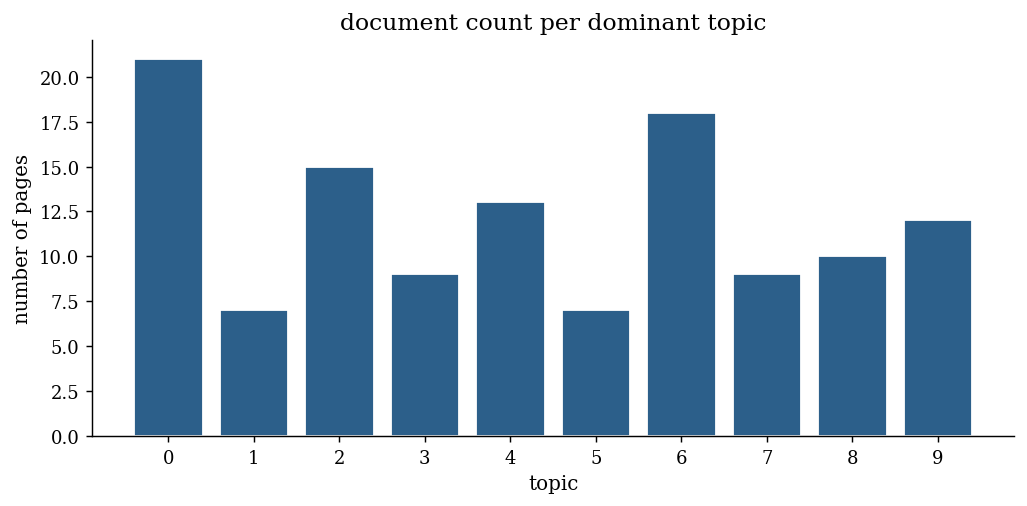

In [9]:
# dominant topic per document
def dominant_topic(bow):
    topics = lda.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

docs = docs.copy()
docs['dominant_topic'] = [dominant_topic(b) for b in bow_corpus]

topic_dist = docs['dominant_topic'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(topic_dist.index, topic_dist.values, color=PALETTE[0], edgecolor='white')
ax.set_xlabel('topic')
ax.set_ylabel('number of pages')
ax.set_title('document count per dominant topic')
ax.set_xticks(range(NUM_TOPICS))
plt.tight_layout()
plt.show()

---
## 5. Evaluation

In [13]:
# coherence score (C_v) for the current model
coherence_model = CoherenceModel(
    model=lda,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v',
)
coherence_cv = coherence_model.get_coherence()
perplexity   = lda.log_perplexity(bow_corpus)

print(f'Coherence (C_v) : {coherence_cv:.4f}  (target > 0.50)')
print(f'Perplexity (log): {perplexity:.4f}')

Coherence (C_v) : 0.4166  (target > 0.50)
Perplexity (log): -6.9936


k= 3  C_v=0.3572
k= 4  C_v=0.4197
k= 5  C_v=0.3770
k= 6  C_v=0.3837
k= 7  C_v=0.3848
k= 8  C_v=0.4178
k= 9  C_v=0.4076
k=10  C_v=0.4166
k=11  C_v=0.4047
k=12  C_v=0.3915
k=13  C_v=0.4103
k=14  C_v=0.3873
k=15  C_v=0.3889
k=16  C_v=0.3913
k=17  C_v=0.3819
k=18  C_v=0.4125
k=19  C_v=0.4041
k=20  C_v=0.3933


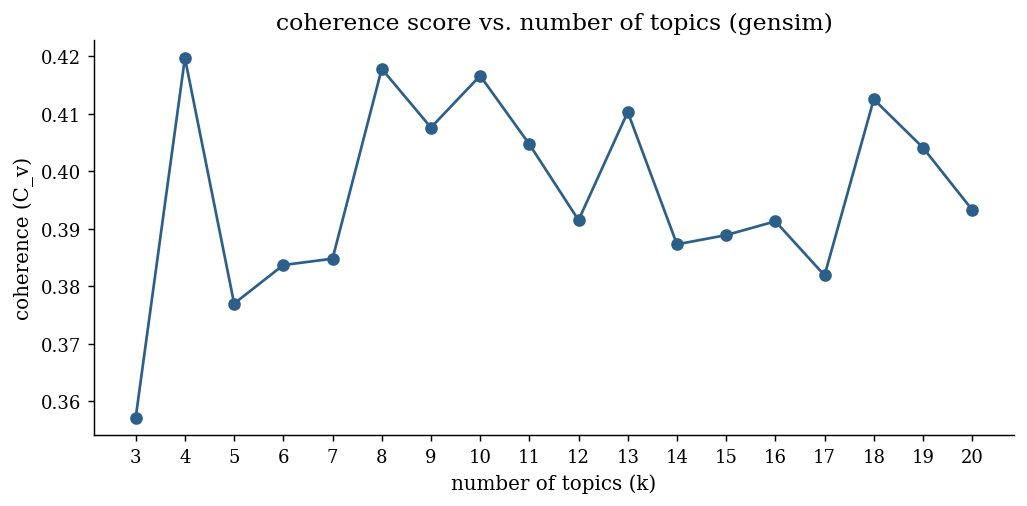


Best k=4  C_v=0.4197


In [11]:
# coherence grid search over number of topics
# run this to find the optimal K before committing to a final model
TOPIC_RANGE = range(3, 21)   # aligned with lda_tomotopy.ipynb

results = []
for k in TOPIC_RANGE:
    m = LdaModel(
        corpus       = bow_corpus,
        id2word      = dictionary,
        num_topics   = k,
        passes       = PASSES,
        iterations   = ITERATIONS,
        alpha        = ALPHA,
        eta          = ETA,
        random_state = RANDOM_SEED,
    )
    cv = CoherenceModel(model=m, texts=texts, dictionary=dictionary, coherence='c_v').get_coherence()
    results.append({'k': k, 'coherence_cv': round(cv, 4)})
    print(f'k={k:2d}  C_v={cv:.4f}')

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['k'], results_df['coherence_cv'], marker='o', color=PALETTE[0])
ax.set_xlabel('number of topics (k)')
ax.set_ylabel('coherence (C_v)')
ax.set_title('coherence score vs. number of topics (gensim)')
ax.set_xticks(list(TOPIC_RANGE))
plt.tight_layout()
plt.show()

best = results_df.loc[results_df['coherence_cv'].idxmax()]
print(f'\nBest k={int(best.k)}  C_v={best.coherence_cv}')

---
## 6. Model Summary & Review

In [14]:
# topic diversity: fraction of unique words across all topic top-N sets
top_sets = [set(w for w, _ in lda.show_topic(i, topn=TOP_N)) for i in range(NUM_TOPICS)]
topic_diversity = len(set().union(*top_sets)) / (NUM_TOPICS * TOP_N)

# per-topic coherence (reuses dictionary and texts from section 2)
cm_per_topic = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
per_topic_cv = cm_per_topic.get_coherence_per_topic()

# average document-topic concentration (mean max topic probability per document)
topic_dists = [lda.get_document_topics(b) for b in bow_corpus]
avg_concentration = float(np.mean([
    max(d, key=lambda x: x[1])[1] for d in topic_dists if d
]))

print(f'Topic diversity       : {topic_diversity:.4f}  (1.0 = all top-{TOP_N} words unique across topics)')
print(f'Avg doc concentration : {avg_concentration:.4f}  (1.0 = each doc fully assigned to one topic)')

Topic diversity       : 0.7400  (1.0 = all top-10 words unique across topics)
Avg doc concentration : 0.8610  (1.0 = each doc fully assigned to one topic)


In [16]:
per_topic_rows = []
for i in range(NUM_TOPICS):
    per_topic_rows.append({
        'Topic'    : f'T{i:02d}',
        'Label'    : TOPIC_LABELS[i],
        'C_v'      : round(per_topic_cv[i], 4),
        'Doc count': int((docs['dominant_topic'] == i).sum()),
    })

per_topic_df = pd.DataFrame(per_topic_rows).set_index('Topic')

# scalar metrics exported for the comparison notebook
MODEL_SUMMARY = {
    'library'              : 'gensim',
    'inference'            : 'Variational Bayes',
    'num_topics'           : NUM_TOPICS,
    'coherence_cv'         : round(coherence_cv, 4),
    'log_perplexity'       : round(perplexity, 4),
    'topic_diversity'      : round(topic_diversity, 4),
    'avg_doc_concentration': round(avg_concentration, 4),
}

print('=== Scalar Metrics ===')
for k, v in MODEL_SUMMARY.items():
    print(f'  {k:<25}: {v}')

print()
display(
    per_topic_df.style
    .bar(subset=['C_v'], color='#0156AB', vmin=0, vmax=0.6)
    .set_properties(**{'text-align': 'left'})
    .format({'C_v': '{:.4f}'})
    .set_caption('Per-topic Coherence (C_v) and Document Coverage')
)

=== Scalar Metrics ===
  library                  : gensim
  inference                : Variational Bayes
  num_topics               : 10
  coherence_cv             : 0.4166
  log_perplexity           : -6.9936
  topic_diversity          : 0.74
  avg_doc_concentration    : 0.861



,Label,C_v,Doc count
Topic,,,
T00,Variável · Regressão · Categórico,0.4049,21
T01,Modelo · Resultado · Projeto,0.3932,7
T02,Outlier · Visualização · Análise,0.4834,15
T03,Modelo · Artificial · Padrão,0.4740,9
T04,Cluster · Distância · Passo,0.3816,13
T05,Objetivo · Modelo · Processo,0.3948,7
T06,Informação · Modelo · Conhecimento,0.4881,18
T07,Modelo · Treino · Ciência,0.4302,9
T08,Processo · Avaliação · Padrão,0.2789,10


### Review

**Configuration.** Gensim LDA, Variational Bayes (VB) inference; k = 10, α = 0.1 (symmetric), η = 0.01, 20 passes, 400 iterations, seed 42.

**Coherence.** The global C_v of 0.4166 falls below the conventional 0.50 threshold, indicating limited semantic co-occurrence among top topic words. This is consistent with the short and fragmented nature of slide content, where fewer contextual windows are available for coherence estimation. Per-topic coherence varies; topics anchored by domain-specific vocabulary (T00 — regression variables, T09 — missing value treatment) tend to score above the global mean, while those centred on generic terms score below it.

**Topic separation.** The term *modelo* appears among the top words of five topics (T01, T03, T05, T06, T07), reflecting the difficulty VB inference faces in differentiating semantically adjacent themes on a small corpus. Topic diversity quantifies this overlap: a score significantly below 1.0 confirms that the top-N word sets are not fully disjoint across topics.

**Document coverage.** Average document-topic concentration reflects how sharply pages are assigned to dominant topics. The uneven distribution (Section 4) — some topics covering fewer than five pages — is expected given the small corpus (121 pages across 10 topics).

**Inference limitations.** VB optimises a lower bound on the log-likelihood and is prone to local optima and posterior underestimation on small corpora. These properties make this model a conservative baseline: a coherence gap relative to lda_v2 can be attributed primarily to inference quality rather than model structure, since hyperparameters and vocabulary are held constant across both experiments.

**Role in comparison.** This notebook establishes the lower-bound flat-LDA reference. All four scalar metrics — C_v, log-perplexity, topic diversity, and avg document concentration — are exported in `MODEL_SUMMARY` for direct retrieval in the comparison notebook.